# Income Analysis Project

## Question:
Do people who work more than 40 hours per week tend to earn more than 50K?

In [19]:
import pandas as pd  # load pandas

df = pd.read_csv("adult.data.txt", header=None)  # read dataset

df.columns = ["age","workclass","fnlwgt","education","education_num",
              "marital_status","occupation","relationship","race","sex",
              "capital_gain","capital_loss","hours_per_week","native_country","income"]  # set column names

print(df.shape)  # size of dataset
df.head()  # preview data

(32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [21]:
print(df.describe())  # basic stats
print(df["income"].value_counts())  # count income groups


                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [26]:
count = 0  # track people meeting condition

for i in range(len(df)):
    if df.loc[i, "hours_per_week"] > 40:
        if df.loc[i, "income"] == " >50K":
            count += 1  # increase when both are true

print(count)  # result

3856


In [23]:
avg_hours = df["hours_per_week"].mean()  # average hours

if avg_hours > 40:
    print("People work more than 40 hours")
elif avg_hours == 40:
    print("Exactly 40 hours")
else:
    print("Less than 40 hours")  # interpret result

People work more than 40 hours


In [24]:
def avg_hours_by_income(data, income_label):
    """return avg hours for given income group"""
    subset = data[data["income"] == income_label]
    return subset["hours_per_week"].mean()  # compute mean

print(avg_hours_by_income(df, " >50K"))
print(avg_hours_by_income(df, " <=50K"))

45.473026399693914
38.840210355987054


In [10]:
import numpy as np

hours_array = df["hours_per_week"].to_numpy()

# Vectorized operation
print("Mean hours:", np.mean(hours_array))

# Boolean masking
long_hours = hours_array[hours_array > 40]
print("People working >40 hours:", len(long_hours))

# Index access
print("First person's hours:", hours_array[0])

Mean hours: 40.437455852092995
People working >40 hours: 9581
First person's hours: 40


In [11]:
income_hours = {}

# Store average hours by income group
for label in [" >50K", " <=50K"]:
    income_hours[label] = df[df["income"] == label]["hours_per_week"].mean()

print(income_hours)

# Find group with highest value
for key in income_hours:
    if income_hours[key] == max(income_hours.values()):
        print("Group with highest avg hours:", key)

{' >50K': np.float64(45.473026399693914), ' <=50K': np.float64(38.840210355987054)}
Group with highest avg hours:  >50K


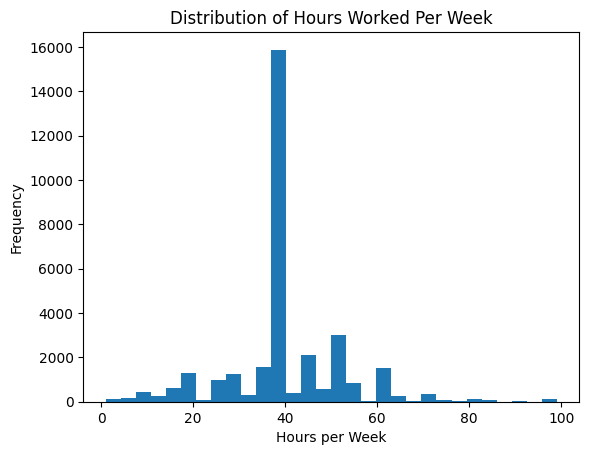

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["hours_per_week"], bins=30)
plt.title("Distribution of Hours Worked Per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Frequency")
plt.show()

The histogram shows that most people work around 40 hours per week. 
The distribution appears slightly right-skewed.

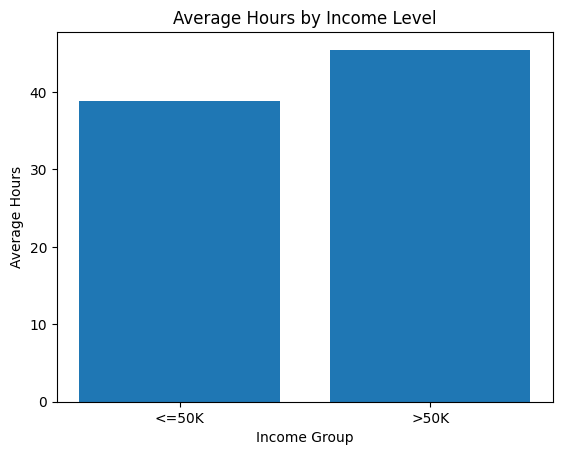

In [13]:
avg_hours = [
    avg_hours_by_income(df, " <=50K"),
    avg_hours_by_income(df, " >50K")
]

labels = ["<=50K", ">50K"]

plt.bar(labels, avg_hours)
plt.title("Average Hours by Income Level")
plt.xlabel("Income Group")
plt.ylabel("Average Hours")
plt.show()

This bar chart compares average working hours between income groups. 
People earning more than 50K tend to work slightly more hours.


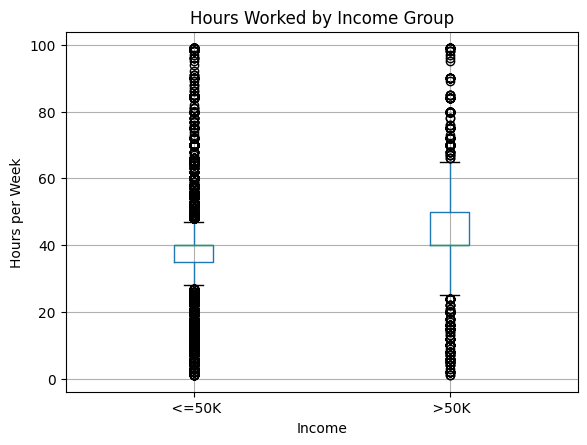

In [27]:
import matplotlib.pyplot as plt

df.boxplot(column="hours_per_week", by="income")
plt.title("Hours Worked by Income Group")
plt.suptitle("")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()

In [18]:
import numpy as np

x = df["hours_per_week"].to_numpy()
y = df["education_num"].to_numpy()

# compute correlation
correlation = np.corrcoef(x, y)[0,1]

print("Correlation between hours worked and education level:", correlation)

Correlation between hours worked and education level: 0.14812273262291134


## Interpretation

The connection between hours worked and education level is poor. 
This helps us see that working more hours does not strongly contribute to education level, 
and other things likely influence income more highly.

